# **线性回归**


线性回归是一种用于**预测连续数值**的监督学习算法。它的目标是找到特征（输入变量）与目标（输出变量）之间的**线性**关系。

简单来说就是用一条线来表示数据之间的关系。

## **一元线性回归**


只有一个特征数据的,就是一元线性回归

$ y = kx+b$

一般也写成

$ y=w_1x+w_0$

- $w_1$: 权重参数(斜率)，表示特征与目标之间的关联强度。
- $w_0$: 偏置参数(截距)，表示模型在数据中的偏移量。
- $x$: 特征值。
- $y$: 目标值。


> 举个例子:假如房子的价格只受房子面积影响,我们要根据房子面积来预测价格.

> 数据:

> | 房子面积($m^2$) | 房子价格(万元) |
> |-------------|----------|
> | 50          | 80       |
> | 80          | 150      |
> | 100         | 180      |
> | 120         | 200      |
> | 150         | 250      |
> | 180         | ?        |

> 图表:



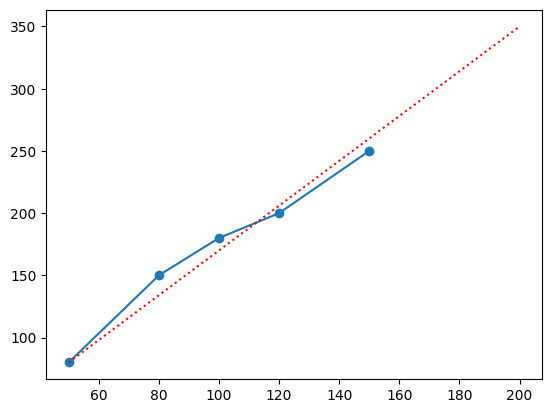

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 这里的代码只是用于画图而已
x = np.array([50, 80, 100, 120, 150])
y = np.array([80, 150, 180, 200, 250])
x2 = np.array([50, 200])
y2 = np.array([80, 350])
plt.plot(x, y, marker='o')
plt.plot(x2, y2, linestyle='dotted', color='red')
plt.show()

> 蓝色的线是真实的数据,红色的线是我们找到的"最佳"直线.借助红色的线,我们就能预测出180平的房屋售价是多少.

### 代码演示

In [14]:
from sklearn.linear_model import LinearRegression

#1.准备数据
x_train = np.array([[50], [80], [100], [120], [150]])  # 特征数据
y_train = np.array([80, 150, 180, 200, 250])  # 标签
x_test = np.array([[180]])  # 预测数据
#2.模型训练
model = LinearRegression()
model.fit(x_train, y_train)
print("权重(斜率):", model.coef_)
print("偏置(截距):", model.intercept_)
print("预测180平房屋价格:", model.predict(x_test))

权重(斜率): [1.63793103]
偏置(截距): 8.206896551724128
预测180平房屋价格: [303.03448276]


## **多元线性回归**


多元线性回归,就是多个特征数据.

$ y = k_1x_1+k_2x_2+k_3x_3+ ... +k_nx_n+b $

或者

$y = w_0+w_1x_1+w_2x_2+w_3x_3+ ... +w_nx_n = w^Tx$

- $w_1$: 权重参数(斜率)，表示特征与目标之间的关联强度。
- $w_0$: 偏置参数(截距)，表示模型在数据中的偏移量。
- $x$: 特征值。
- $y$: 目标值。

为什么可以用 $y = w^Tx$ 来表示呢

$w = \begin{pmatrix}
w_1&w_2&w_3&...&w_n\\
\end{pmatrix}$

$x = \begin{pmatrix}
x_1&x_2&x_3&...&x_n\\
\end{pmatrix}$

 $w^Tx$ 的结果就是:

$$w^Tx = \begin{pmatrix}
w_0\\
w_1\\
w_2\\
w_3\\
...\\
w_n\\
\end{pmatrix} * \begin{pmatrix}
1&x_1&x_2&x_3&...&x_n\\
\end{pmatrix} = w_0+w_1x_1+w_2x_2+w_3x_3+...+w_nx_n$$

> 举个例子:房子的价格不止受面积的影响,还有房子位置,房子朝向,房子楼层等等
> 数据:
>
>| 房子面积($m^2$) | 房子位置 | 房子朝向 | 房子楼层 | 房子价格(万元) |
>|-------------|----------|----------|----------|----------|
>| 50          | 1        | 1        | 1        | 80       |
>| 80          | 1        | 1        | 2        | 150      |
>| 100         | 1        | 1        | 3        | 180      |
>| 120         | 1        | 1        |4          | 200|
>
>$x$是表示标签的:
>- $x_1$:房子面积
>- $x_2$:房子位置
>- $x_3$:房子朝向
>- $x_4$:房子楼层
>
>$w$表示标签的数值:
>- $w_1$:房子面积的数值
>- $w_2$:房子位置的数值
>- $w_3$:房子朝向的数值
>- $w_4$:房子楼层的数值

## **损失函数**

我们需要一个标准来衡量直线的好坏,这就是**损失函数**


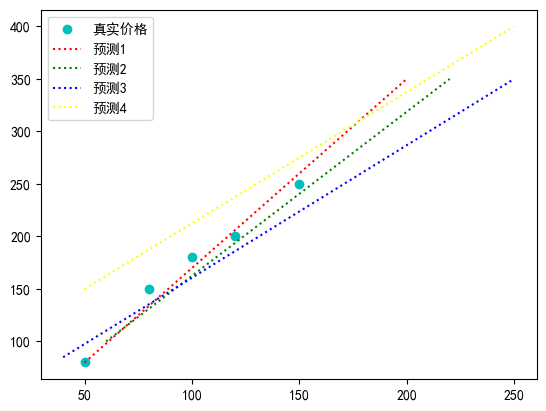

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 这里的代码只是用于画图而已
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
x = np.array([50, 80, 100, 120, 150])
y = np.array([80, 150, 180, 200, 250])
x2 = np.array([50, 200])
y2 = np.array([80, 350])
plt.plot(x, y, 'o', color='c', label='真实价格')
plt.plot(x2, y2, linestyle='dotted', color='red', label='预测1')
plt.plot([60, 220], [100, 350], linestyle='dotted', color='green', label='预测2')
plt.plot([40, 250], [85, 350], linestyle='dotted', color='blue', label='预测3')
plt.plot([50, 250], [150, 400], linestyle='dotted', color='yellow', label='预测4')
plt.legend()
plt.show()

如上图所示,有四条线,哪条线最接近真实数据呢?那条线才是最好的呢?

**损失函数**: 也叫做成本函数,代价函数,目标函数.每个样本点 和 其预测值之间的关系,损失函数越小,说明预测值和样本点越接近

常用的损失函数是**均方误差(Mean-Square Error,MSE)**:

$$MSE = \frac{1}{n}\sum_{i=1}^{n}(\hat{y_i}-y_i)^2$$
- $n$是样本点的个数
- $y_i$是样本点对应的真实值
- $\hat{y_i}$是样本点对应的预测值

一般使用**正规方程法**和**梯度下降法**求解损失函数.

### **正规方程法**(了解)

列出数学方程求出精确解

**优点**:一步就可以求出精确解.

**缺点**:计算量非常大,不适合大数据集

#### **前置知识**

**复杂函数的求导**: 先对外函数求导,再对内函数求导
> $f(x) = (x^2+2x)^2$
>
> $f'(x) = 2(x^2+2x)^1(x^2+2x)' = 2(x^2+2x)(2x+2) = 4x^3+12x+8x$


**偏导**: 固定其他，只变一个,把其他变量都当作常数.比如对x求导,则可以将y看成常数项
>$ f(x,y) = (x - 2)^2 + (y - 3)^2$
>
> 对y求导: $f_y(x,y) = \frac{\partial f}{\partial y} = 2(y-3)$
>
> 对x求导: $f_x(x,y) = \frac{\partial f}{\partial x} = 2(x-2)$

#### **一元线性回归_损失函数_正规方程法_推演过程**

根据公式: $MSE = \frac{1}{n}\sum_{i=1}^{n}(\hat{y_i}-y_i)^2$

其中$\hat{y_i}$是预测值, $y_i$是真实值

所以$\hat{y_i}$可以表示为:
$\hat{y_i} = kx_i + b$

1. 求$k$的偏导:

① $f(k,b) = MSE = 0 =\frac{1}{n}\sum_{i=1}^{n}(kx_i+b-y_i)^2$


②$f_k(k,b) = 0 = \frac{\partial f}{\partial k} = \frac{1}{n}\sum_{i=1}^{n}(2(kx_i+b-y_i)(kx_i+b-y_i)')$

因为对$k$求偏导,其他变量都当作常数,所以$(kx_i+b-y_i)'$ 就只有$x_i$

③$0  = \frac{1}{n}\sum_{i=1}^{n}(2(kx_i+b-y_i)x_i)$

④$0 = \sum_{i=1}^{n}(kx_i^2+bx_i-x_iy_i)$

⑤$0 = k\sum_{i=1}^{n}x_i^2+b\sum_{i=1}^{n}x_i-\sum_{i=1}^{n}x_iy_i$

2. 求$b$的偏导:

⑥$f_b(k,b) = 0 = \frac{\partial f}{\partial k} = \frac{1}{n}\sum_{i=1}^{n}(2(kx_i+b-y_i)(kx_i+b-y_i)')$

因为对$b$求偏导,其他变量都当作常数,所以$(kx_i+b-y_i)'$ 就只有$1$

⑦$0 = \frac{1}{n}\sum_{i=1}^{n}(2(kx_i+b-y_i)*1))$

⑧$0 = k\sum_{i=1}^{n}x_i + nb - \sum_{i=1}^{n}y_i$


> | $x$房子面积($m^2$) | $y$房子价格(万元) |
> |----------------|-------------|
> | 50             | 80          |
> | 80             | 150         |
> | 100            | 180         |
> | 120            | 200         |
> | 150            | 250         |
> | 180            | ?           |
>
> 比如这个数据,我们可以使用推导的公式⑤和公式⑧得到:
>
> ⑤->$0 = k(50^2+80^2+100^2+120^2+150^2) + b(50+80+100+120+150) - (50*80+80*150+100*180+120*200+150*250)$
>
> ⑨ $0 = 55800k + 500b - 95500$
>
> ⑧->$0 = k(50+80+100+120+150) + 5b - (80+150+180+200+250)$
>
> ⑩ $0 = 500k + 5b - 860$
>
> 联立⑨⑩,得到:
>
> $k = \frac{95}{58} \approx 1.6379$
>
> $b = \frac{238}{29} \approx 8.2069$
>
> 所以 $y = kx+b$ -> $y = 1.6379x+8.2069$
>
> 预测180平方米的房子价格: $y = 1.6379*180+8.2069= 303.0289$
>
> 303.0289与代码输出的303.03448276很接近



#### **多元线性回归_损失函数_正规方程法_推演过程**

已知多元线性回归方程为:

$w^Tx =x^Tw =  \begin{pmatrix}
w_0\\
w_1\\
w_2\\
w_3\\
...\\
w_n\\
\end{pmatrix} * \begin{pmatrix}
1&x_1&x_2&x_3&...&x_n\\
\end{pmatrix} = w_0+w_1x_1+w_2x_2+w_3x_3+...+w_nx_n$

所以可以得知第一个样本的预测值为:

$ w^Tx_1 =  w_0+w_1x_{1,1}+w_2x_{1,2}+w_3x_{1,3}+...+w_dx_{1,d}$

- $d$: 特征个数

第一个样本的预测值为:

$ (\hat{y_1} - y_1)^2 = (w_0+w_1x_{1,1}+w_2x_{1,2}+w_3x_{1,3}+...+w_dx_{1,d} - y_1)^2 = (\sum_{j=1}^{d}(w_jx_{1,j}+w_0)-y_1)^2$

n个样本损失最小,就是把所有样本最小损失函数求和:

$j(w) = \sum_{i=1}^{n}((\sum_{j=1}^{d}(w_jx_{i,j}+w_0)-y_i)^2)$

这个公式和**损失函数**几乎一样,我们可以写成:

$k(x_i) = \sum_{j=1}^{d}(w_jx_{i,j}+w_0) =x^Tw $

$ j(w) = \sum_{i=1}^{n}x^Tw-y)^2$

针对$w$求偏导:

$0 = \frac{\partial j}{\partial w} = 2(x^Tw-y)*x^T$

$ 0 =(x^Tw-y)*x^T*x $

$ 0 = (x^Tw-y)*(x^T*x)(x^T*x)^-1$

$ 0 = x^Tw -y$

$  x*x^Tw =xy$

$(x*x^T)^-1(x*x^T)*w = (x*x^T)^-1*xy$

$w = (x*x^T)^-1*xy$




